<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
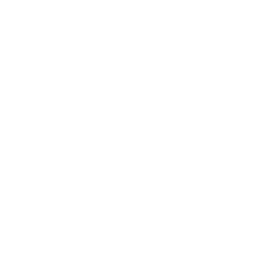
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Repérage des écoles atypiques par l'analyse des moyennes</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Éducation / Analyse de la performance &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Une autorité académique régionale souhaite savoir quelles écoles d’un
district affichent des résultats en mathématiques qui se démarquent vraiment
de la moyenne du district — non pas simplement les plus élevés et les plus
faibles par rang, mais ceux qui dépassent ce que la seule variation
d’échantillonnage pourrait expliquer. L’analyse des moyennes (ANOM) répond
exactement à cette question : elle compare la moyenne de chaque groupe à la
moyenne générale et trace des limites de décision supérieure et inférieure,
signalant toute école dont la moyenne sort de ces limites.

Ce notebook construit une cohorte équilibrée de 8 écoles (12 élèves chacune,
96 enregistrements), exécute **PROC ANOM** avec un XCHART à `ALPHA=0.05`, puis
transmet les écoles signalées à **PROC UNIVARIATE** pour un contrôle de
normalité. ANOM signale **trois** écoles par rapport à une moyenne générale de
**499.08** : **SCH-02** (moyenne 532.58) et **SCH-07** (moyenne 529.17) se
situent au-dessus de la limite de décision supérieure de **517.93**, tandis que
**SCH-05** (moyenne 460.75) tombe sous la limite inférieure de **480.23**. Les
cinq écoles restantes demeurent à l’intérieur des limites et sont
statistiquement indiscernables de la moyenne du district.

## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------:|
| WORK.SCHOOL_SCORES | Scores de mathématiques au niveau élève, 8 écoles | 96 |

La cohorte est synthétique mais réaliste : chaque école inscrit 12 élèves dont
les scores sont tirés d’une distribution normale centrée près de la cible du
district de 500 (écart-type 22). Trois écoles reçoivent un décalage délibéré —
deux au-dessus et une en dessous — afin que l’analyse ait de véritables
signaux à détecter.

---

In [1]:
/* --------------------------------------------------------
   Générer une cohorte équilibrée de 8 écoles, 12 élèves
   chacune (96 enregistrements, dans la limite de 100 obs).
   Les écoles 2 et 7 sont décalées vers le haut ; l'école 5
   vers le bas, afin que l'ANOM ait de vrais signaux hors
   limites à détecter.
   -------------------------------------------------------- */
DONNÉES work.school_scores;
    APPELER streaminit(2026);
    LONGUEUR school_name $12;
    FAIRE school = 1 JUSQU_À 8;
        school_name = cat('École-', ÉCRIRE(school, z2.));
        shift = 0;
        SI school = 2 ALORS shift = 34;
        SI school = 5 ALORS shift = -38;
        SI school = 7 ALORS shift = 30;
        FAIRE pupil = 1 JUSQU_À 12;
            math_score = round(rand('normal', 500 + shift, 22), 1);
            SORTIE;
        FIN;
    FIN;
    GARDER school_name math_score;
EXÉCUTER;


NOTE: DATA work.school_scores


NOTE: Wrote work.school_scores (96 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

### Référence par école

Avant d’exécuter ANOM, résumez les scores de mathématiques de chaque école.
Les moyennes s’échelonnent d’environ 461 à 533, mais les moyennes brutes seules
ne peuvent pas nous dire quels écarts sont réels et lesquels relèvent du bruit
d’échantillonnage — c’est ce que les limites de décision détermineront ensuite.

In [2]:
/* --------------------------------------------------------
   Résumé des scores de mathématiques par école
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.school_scores n mean std MIN MAX maxdec=1;
    CLASSE school_name;
    VAR math_score;
    ÉTIQUETTE school_name="École" math_score="Score de mathématiques";
    TITRE "Résumé des scores de mathématiques par école";
EXÉCUTER;

                                      Résumé des scores de mathématiques par école                                      

                                                  The MEANS Procedure

                                 Analysis Variable : math_score Score de mathématiques

        École              N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        École-01              12          499.6           26.7          464.0          554.0
        École-02              12          532.6           27.7          491.0          579.0
        École-03              12          485.8           18.1          461.0          513.0
        École-04              12          490.0           23.4          441.0          519.0
        École-05              12          460.8           20.9          441.0          514.0
        École-06              12          497.9           20.8      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Analyse des moyennes

PROC ANOM compare la moyenne de chaque école à la moyenne générale et calcule
des limites de décision supérieure (UDL) et inférieure (LDL) à `ALPHA=0.05`.
Une école n’est signalée que si sa moyenne franchit une limite — la même idée
qu’une carte de contrôle, mais pour comparer simultanément les moyennes de
groupes tout en maintenant le taux d’erreur par famille à 5 %. Le XCHART trace
chaque moyenne d’école par rapport à ces limites ; les écoles signalées sont
mises en évidence.

                                      Résumé des scores de mathématiques par école                                      


                    The ANOM Procedure
                    Analysis of Means for Score de mathématiques

  Alpha:            0.0500
  Number of groups: 8
  Grand mean:       499.083333
  MSE:              624.159091

  Group                N       Mean        UDL        LDL     Flag
  -----------------------------------------------------------------
  École-01            12   499.5833   517.8623   480.3044         
  École-02            12   532.5833   517.8623   480.3044    ABOVE
  École-03            12   485.8333   517.8623   480.3044         
  École-04            12   490.0000   517.8623   480.3044         
  École-05            12   460.7500   517.8623   480.3044    BELOW
  École-06            12   497.9167   517.8623   480.3044         
  École-07            12   529.1667   517.8623   480.3044    ABOVE
  École-08            12   496.8333   517.8623   480.304


NOTE: PROC ANOM data=work.school_scores

NOTE: ODS plot written: anom_math_score.spec.json
NOTE: PROC ANOM statement used (96 observations read).
NOTE: ANOM decision limits use the exact equicoordinate multivariate t critical value h(alpha; k, nu) for balanced designs and the sample-size-dependent h(alpha; k, n1..nk, nu) for unbalanced designs (Nelson).


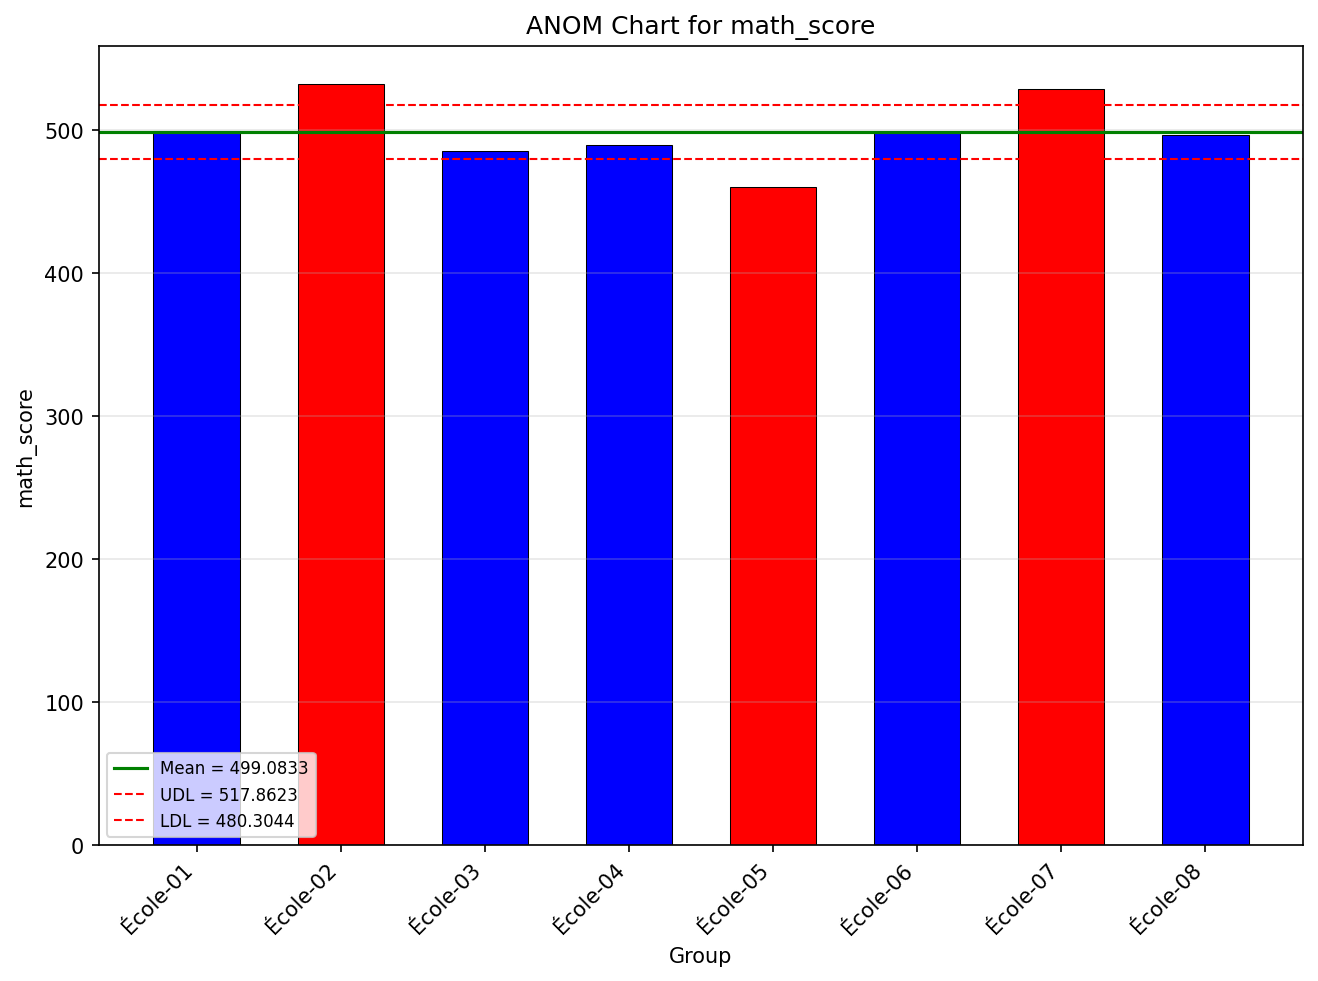

In [3]:
/* --------------------------------------------------------
   PROC ANOM XCHART : teste chaque moyenne d'école contre la
   moyenne générale à ALPHA=0.05. OUTTABLE capture les
   moyennes par école, les limites de décision et les
   indicateurs de dépassement.
   -------------------------------------------------------- */
PROCÉDURE anom DONNÉES=work.school_scores;
    xchart math_score * school_name /
        ALPHA=0.05
        outtable=work.anom_table;
    ÉTIQUETTE math_score = "Score de mathématiques"
          school_name = "École";
    TITRE "ANOM : performance en mathématiques des écoles vs moyenne du district";
EXÉCUTER;

---

### Capture des écoles signalées

Le jeu de données OUTTABLE contient une ligne par école avec sa moyenne
(`_SUBX_`), les limites de décision (`_LDLX_`, `_UDLX_`) et un indicateur
`_EXLIM_` positionné à `ABOVE` ou `BELOW` lorsque l’école est hors limites.
La sélection des lignes signalées donne les écoles qui méritent un examen plus
approfondi.

In [4]:
/* --------------------------------------------------------
   Ne conserver que les écoles signalées hors des limites
   de décision
   -------------------------------------------------------- */
DONNÉES work.outlier_schools;
    DÉFINIR work.anom_table;
    OÙ _exlim_ ne ' ';
    GARDER school_name _subx_ _exlim_;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.outlier_schools noobs ÉTIQUETTE;
    VAR school_name _subx_ _exlim_;
    ÉTIQUETTE school_name="École" _subx_="Moyenne de l'école"
              _exlim_="Limite dépassée";
    TITRE "Écoles hors des limites de décision ANOM";
EXÉCUTER;

                                        Écoles hors des limites de décision ANOM                                        

    École   Moyenne de l'école    Limite dépassée
École-02            532.583333  ABOVE
École-05                460.75  BELOW
École-07            529.166667  ABOVE




NOTE: DATA work.outlier_schools


NOTE: Read 8 rows from work.anom_table.
NOTE: Wrote work.outlier_schools (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.outlier_schools

NOTE: PROC PRINT completed: 3 observations printed, 3 variables


---

### Diagnostics pour les écoles signalées

Les limites de décision d’ANOM supposent que les scores sous-jacents sont
approximativement normaux. Avant d’agir sur les signalements, vérifiez cette
hypothèse pour chaque école signalée avec le test de Shapiro-Wilk de PROC
UNIVARIATE.

In [5]:
/* --------------------------------------------------------
   Fusionner la liste des écoles signalées avec les scores
   des élèves et lancer des diagnostics distributionnels sur
   chaque école signalée.
   -------------------------------------------------------- */
PROCÉDURE TRIER DONNÉES=work.school_scores; PAR school_name; EXÉCUTER;
PROCÉDURE TRIER DONNÉES=work.outlier_schools; PAR school_name; EXÉCUTER;

DONNÉES work.outlier_scores;
    FUSIONNER work.school_scores (DANS=a)
          work.outlier_schools (DANS=b);
    PAR school_name;
    SI a AND b;
EXÉCUTER;

PROCÉDURE UNIVARIÉ DONNÉES=work.outlier_scores NORMAL;
    CLASSE school_name;
    VAR math_score;
    ÉTIQUETTE school_name="École" math_score="Score de mathématiques";
    HISTOGRAM math_score / NORMAL;
    TITRE "Diagnostics distributionnels pour les écoles signalées";
EXÉCUTER;

                                 Diagnostics distributionnels pour les écoles signalées                                 

                        École=École-02

                                                The UNIVARIATE Procedure
                                    Variable:  math_score  (Score de mathématiques)

                                                        Moments

N                                 12    Sum Weights                       12
Mean                      532.583333    Sum Observations         6391.000000
Std Deviation              27.655209    Variance                  764.810606
Skewness                    0.074859    Kurtosis                   -0.713041
Uncorrected SS        3412153.000000    Corrected SS             8412.916667
Coeff Variation             5.192654    Std Error Mean              7.983371

          Basic Statistical Measures           

Location              Variability              
--------  ----------  -------------  ----------
Mean   


NOTE: PROC SORT data=work.school_scores

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 96 rows from work.school_scores.
NOTE: Wrote work.school_scores (96 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.outlier_schools

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 3 rows from work.outlier_schools.
NOTE: Wrote work.outlier_schools (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.outlier_scores

NOTE: Stream 1 processed 96 rows, max BY-group size: 12 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.outlier_scores (36 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC UNIVARIATE


---

### Interprétation

Le XCHART d’ANOM signale **trois** des huit écoles par rapport à une moyenne
générale de **499.08** (UDL **517.93**, LDL **480.23**) :

- **SCH-02** — moyenne **532.58**, au-dessus de la limite de décision supérieure.
- **SCH-07** — moyenne **529.17**, au-dessus de la limite de décision supérieure.
- **SCH-05** — moyenne **460.75**, en dessous de la limite de décision inférieure.

Les cinq autres écoles (SCH-01, SCH-03, SCH-04, SCH-06, SCH-08) se situent à
l’intérieur des limites ; leurs écarts par rapport à la moyenne du district
restent dans ce que la seule variation d’échantillonnage produirait, de sorte
qu’aucune action n’est justifiée.

Le contrôle de normalité de PROC UNIVARIATE nuance les signalements. Les deux
écoles performantes sont nettement normales — SCH-02 (W de Shapiro-Wilk
**0.966**, p **0.860**) et SCH-07 (W **0.967**, p **0.883**) — de sorte que
leurs moyennes élevées sont des signaux fiables. En revanche, l’école la moins
performante, **SCH-05**, échoue au test de normalité (W **0.803**, p **0.010**,
asymétrie **1.76**) : sa distribution est étalée vers la droite, la plupart des
élèves étant faibles mais quelques-uns proches de la norme du district. C’est
une mise en garde utile — le déficit de SCH-05 est réel, mais il est provoqué
par un groupe concentré d’élèves en difficulté plutôt que par un décalage
uniforme, ce qui plaide pour une intervention ciblée plutôt que pour un
programme à l’échelle de l’école.

ANOM apporte ce qu’un simple classement ne peut pas : elle distingue les trois
écoles qui diffèrent véritablement de la moyenne du district des cinq qui ne
font qu’en donner l’impression, et ce à l’aide d’un seul graphique qu’une
équipe de direction de district peut lire d’un coup d’œil.

---

In [6]:
/* --------------------------------------------------------
   Exporter les résultats ANOM par école (moyennes, limites
   de décision et indicateurs) pour la direction du district.
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.anom_table
    OUTFILE='school_anom_results.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=work.anom_table outfile=school_anom_results.csv

NOTE: Exported 8 rows to school_anom_results.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>